# Detector Orientation and the GW Radiometer

This notebook show how the relative orientation angle $\phi_{\rm rot}$ between two L-shaped gravitational-wave detectors (AB) affects the sensitivity of a cross-correlation radiometer search.

**Contents**
1. Physical constants & detector geometry  
2. Overlap Reduction Function (ORF)  
3. Normalized SNR — isotropic background  
4. Beam matrix with $1/f^6$ spectral weighting  
5. Normalized SNR — kinematic dipole  
6. Point Spread Function (PSF) & dirty maps  

## 1. Setup

In [1]:
%matplotlib inline
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl

mpl.rcParams.update({

    # ---------- Fonts ----------
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,

    # Axis labels
    "axes.labelsize": 16,
    "axes.titlesize": 16,

    # Tick labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    # Legend
    "legend.fontsize": 12,
    "legend.frameon": False,

    # ---------- Lines ----------
    "lines.linewidth": 2.2,

    # ---------- Axes ----------
    "axes.linewidth": 1.2,

    # ---------- Ticks ----------
    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 6,
    "ytick.major.size": 6,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,

    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # ---------- Figure ----------
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # ---------- Grid ----------
    "axes.grid": False,

    # ---------- Color cycle ----------
    "axes.prop_cycle": plt.cycler(color=[
        "#0077BB",
        "#EE7733",
        "#009988",
        "#CC3311",
        "#33BBEE",
        "#EE3377",
    ]),
})
mpl.rcParams["legend.handlelength"] = 2.0
mpl.rcParams["legend.borderaxespad"] = 0.5

## 2. Physical Constants & Detector Geometry

In [2]:
# ── Physical constants ────────────────────────────────────────────────────────
C        = 299792458.0          # speed of light  [m/s]
RE       = 6.37e6               # Earth radius    [m]
SIDDAY   = 86164.0905           # sidereal day    [s]
SIDYR    = 365.25636 * 86400.0  # sidereal year   [s]
AU       = 1.495978707e11       # 1 AU            [m]
OBLIQ    = 23.4392911 * np.pi / 180.0  # Earth obliquity [rad]

# ── ET2L defaults ─────────────────────────────────────────────────────────────
S_DEFAULT = 1.0e6               # detector separation  [m]
L_DEFAULT = 1e4     # arm length                 [m]

print(f"Angular separation θ_AB = {np.degrees(S_DEFAULT/RE):.3f}°")
print(f"Arm light-travel time   = {L_DEFAULT/C*1e6:.3f} μs")

Angular separation θ_AB = 8.995°
Arm light-travel time   = 33.356 μs


### 2.1 Detector Model

Detector **A** is fixed on the equator at $(R_E, 0, 0)$ with arms along $\hat{y}$ and $\hat{z}$.  
Detector **B** is separated by arc-length $d$ and its arms are rotated by angle $\phi_{\rm rot}$ about the local tangent:

$$\hat{u}_B = (-\sin\theta\cos\phi_{\rm rot},\;\cos\theta\cos\phi_{\rm rot},\;\sin\phi_{\rm rot})$$
$$\hat{v}_B = (\sin\theta\sin\phi_{\rm rot},\;-\cos\theta\sin\phi_{\rm rot},\;\cos\phi_{\rm rot})$$

where $\theta = d/R_E$ is the angular separation.


In [3]:
@dataclass
class _Loc:
    lat: float; lon: float; height: float

@dataclass
class _Ori:
    az: float; alt: float

def get_detector(name, alpha=0.0, separation=S_DEFAULT, arm_length=L_DEFAULT):
    """Return (r, u, v, T_arm) for the ET2L detector pair A/B.

    Parameters
    ----------
    name : 'A' or 'B'
    alpha : float
        Orientation angle phi_rot [radians] — only affects detector B.
    separation : float
        Arc-length between A and B on Earth's surface [m].
    arm_length : float
        Arm length [m].

    Returns
    -------
    r : (3,) ndarray   — geocentric position [m]
    u : (3,) ndarray   — unit vector along first arm
    v : (3,) ndarray   — unit vector along second arm
    T : float          — arm light-travel time [s]
    """
    thet = separation / RE
    T    = arm_length / C
    if name == 'A':
        return np.array([RE, 0., 0.]), np.array([0., 1., 0.]), np.array([0., 0., 1.]), T
    if name == 'B':
        return (
            np.array([RE*np.cos(thet), RE*np.sin(thet), 0.]),
            np.array([-np.sin(thet)*np.cos(alpha),  np.cos(thet)*np.cos(alpha),  np.sin(alpha)]),
            np.array([ np.sin(thet)*np.sin(alpha), -np.cos(thet)*np.sin(alpha),  np.cos(alpha)]),
            T)
    raise ValueError(f"Unknown detector '{name}'. Use 'A' or 'B'.")

print(f"Detector separation : {np.degrees(S_DEFAULT/RE):.3f}°  ({S_DEFAULT/1e3:.0f} km)")
print(f"Arm light-travel time: {L_DEFAULT/C*1e6:.3f} μs")


Detector separation : 8.995°  (1000 km)
Arm light-travel time: 33.356 μs


### 2.2 Detector Positions on the Globe

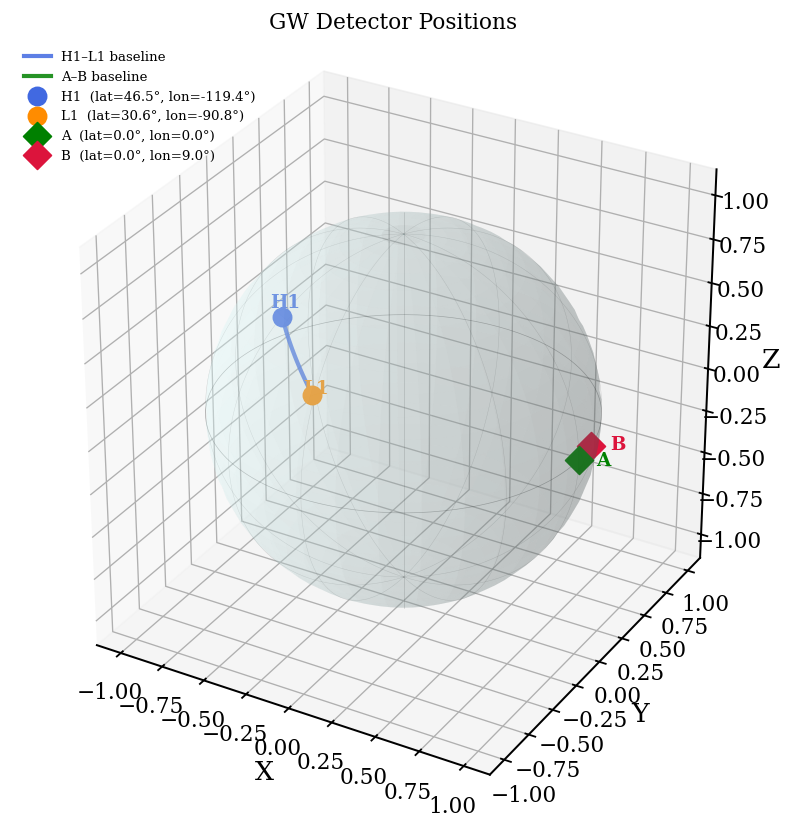

In [4]:
def dms(d, m, s): return d + m/60 + s/3600

_DETS = {
    'H1': dict(lat= dms(46,27,18.528),  lon=-dms(119,24,27.5657), c='royalblue',  mk='o', s=120),
    'L1': dict(lat= dms(30,33,46.4196), lon=-dms(90, 46,27.2654), c='darkorange', mk='o', s=120),
    'A':  dict(lat=0.,  lon=0.,                                    c='green',      mk='D', s=140),
    'B':  dict(lat=0.,  lon=np.degrees(S_DEFAULT/RE),              c='crimson',    mk='D', s=140),
}

def _ll2xyz(lat, lon):
    la, lo = np.radians(lat), np.radians(lon)
    return np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)

def _great_arc(lat1, lon1, lat2, lon2, n=80):
    p1 = np.array(_ll2xyz(lat1, lon1))
    p2 = np.array(_ll2xyz(lat2, lon2))
    omega = np.arccos(np.clip(np.dot(p1,p2), -1, 1))
    ts = np.linspace(0, 1, n)
    if omega < 1e-9:
        return np.tile(p1[:,None], n)
    arc = (np.sin((1-ts)*omega)/np.sin(omega))[:,None]*p1 +           (np.sin(   ts *omega)/np.sin(omega))[:,None]*p2
    return arc  # (n,3)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

# Earth sphere
u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
ax.plot_surface(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                color='lightcyan', alpha=0.20, linewidth=0)
# grid lines
t = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(t), np.sin(t), 0, 'k-', lw=0.4, alpha=0.3)
for lo0 in range(0, 360, 30):
    lo = np.radians(lo0); la = np.linspace(-np.pi/2, np.pi/2, 100)
    ax.plot(np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la),
            'k-', lw=0.3, alpha=0.15)

# baselines
for (n1,n2), clr, lbl in [(('H1','L1'),'royalblue','H1–L1'), (('A','B'),'green','A–B')]:
    d1,d2 = _DETS[n1], _DETS[n2]
    arc = _great_arc(d1['lat'],d1['lon'], d2['lat'],d2['lon'])
    ax.plot(arc[:,0], arc[:,1], arc[:,2], color=clr, lw=2.5, alpha=0.85, label=lbl+' baseline')

# detectors
for name, d in _DETS.items():
    x,y,z = _ll2xyz(d['lat'], d['lon'])
    ax.scatter(x, y, z, c=d['c'], s=d['s'], marker=d['mk'], zorder=5,
               label=f"{name}  (lat={d['lat']:.1f}°, lon={d['lon']:.1f}°)")
    ax.text(x*1.10, y*1.10, z*1.10, name, fontsize=11, color=d['c'], fontweight='bold')

ax.set_box_aspect([1,1,1])
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('GW Detector Positions', fontsize=13)
ax.legend(loc='upper left', fontsize=8, framealpha=0.7)
plt.tight_layout(); plt.show()


## 3. Overlap Reduction Function

The ORF between detectors 1 and 2 is

$$\gamma(f,\phi_{\rm rot}) = \frac{5}{8\pi}\int d^2\Omega_{\hat{k}}\,\sum_{A=+,\times} F_1^A(\hat{k})\,F_2^{A*}(\hat{k})\,e^{\,i2\pi f\,\hat{k}\cdot\Delta\mathbf{r}/c}$$

In the long-wavelength (LW) limit the antenna transfer functions reduce to unity and $\gamma$ is real.


In [5]:
# ── Rotation matrices ─────────────────────────────────────────────────────────
def Ry(a):
    return np.array([[np.cos(a),0,-np.sin(a)],[0,1,0],[np.sin(a),0,np.cos(a)]])
def Rz(a):
    return np.array([[np.cos(a),np.sin(a),0],[-np.sin(a),np.cos(a),0],[0,0,1]])

def _sinch(x):
    x = np.asarray(x, dtype=complex)
    return np.where(x == 0, 1.+0j, np.sinh(x)/x)

def FpFc(f, theta, phi, psi, u, v, T, method='lw'):
    """Plus/cross antenna patterns for one sky direction."""
    f = np.asarray(f, dtype=complex); s = 1j*2*np.pi*f
    R = Rz(psi) @ Ry(theta) @ Rz(phi)
    u = R@u; v = R@v
    ux,uy,uz = u[0],u[1],u[2]
    vx,vy,vz = v[0],v[1],v[2]
    if method == 'lw':
        Tu = Tv = np.ones_like(f)
    elif method == '1st':
        Tu = 1 - s*T*(1 - uz/2)
        Tv = 1 - s*T*(1 - vz/2)
    elif method == 'exact':
        Au =  _sinch( s*T*(1-uz)); Bu = -_sinch(-s*T*(1+uz))
        Av =  _sinch( s*T*(1-vz)); Bv = -_sinch(-s*T*(1+vz))
        Tu = (Au - Bu*np.exp(-2*s*T)) / 2
        Tv = (Av - Bv*np.exp(-2*s*T)) / 2
    Fp = 0.5*(Tu*(ux**2-uy**2) - Tv*(vx**2-vy**2))
    Fc = 0.5*(Tu*(2*ux*uy)     - Tv*(2*vx*vy))
    return Fp, Fc

def compute_overlap(f, alpha, method='lw', nside_pix=4,
                    separation=S_DEFAULT, arm_length=L_DEFAULT):
    """ORF via HEALPix Monte-Carlo (no file needed)."""
    rA,uA,vA,TA = get_detector('A', alpha, separation, arm_length)
    rB,uB,vB,TB = get_detector('B', alpha, separation, arm_length)
    dX     = rA - rB
    npix   = hp.nside2npix(nside_pix)
    th,ph  = hp.pix2ang(nside_pix, np.arange(npix))
    dOmega = 4*np.pi / npix
    orf    = np.zeros(len(f), dtype=complex)
    for ii in range(npix):
        FAp,FAc = FpFc(f, th[ii], ph[ii], 0, uA.copy(), vA.copy(), TA, method)
        FBp,FBc = FpFc(f, th[ii], ph[ii], 0, uB.copy(), vB.copy(), TB, method)
        H       = (5/(8*np.pi)) * (FAp*np.conj(FBp) + FAc*np.conj(FBc))
        nDotDX  = (Ry(th[ii]) @ Rz(ph[ii]) @ dX)[2]
        orf    += H * np.exp(1j*2*np.pi*f*nDotDX/C) * dOmega
    return orf

print("ORF functions defined.  (Using nside_pix=4 → 192 pixels for speed.)")


ORF functions defined.  (Using nside_pix=4 → 192 pixels for speed.)


In [6]:
f = np.linspace(1, 512, 512)
configs = [
    (0,              r'0'),
    (np.pi/8,        r'22.5'),
    (17*np.pi/72,    r'42.5'),
    (np.pi/4,        r'45'),
    (19*np.pi/72,    r'47.5'),
    (3*np.pi/8,      r'67.5'),
    (np.pi/2,        r'90'),
]

STYLE_MAP = {
    '0':    {'color': '#2c7bb6', 'ls': '-',  'lw': 1.5},
    '22.5': {'color': '#5e3c99', 'ls': '-',  'lw': 1.5},
    '42.5': {'color': '#fdae61', 'ls': '-',  'lw': 1.5},
    '45':   {'color': 'r',       'ls': '-',  'lw': 2.5},
    '47.5': {'color': '#fdae61', 'ls': '-.',  'lw': 1.5},
    '67.5': {'color': '#5e3c99', 'ls': '-.',  'lw': 1.5},
    '90':   {'color': '#2c7bb6', 'ls': '-.',  'lw': 1.5},
}


In [7]:
def plot_orf(configs, f, scale='linear'):
    fig, ax = plt.subplots(figsize=(7.0, 5))

    for alpha, label in configs:
        orf = compute_overlap(f, alpha, method='lw', nside_pix=32)

        style = STYLE_MAP[label]

        if scale == 'linear':
            ax.plot(
                f,
                np.real(orf),
                label=rf'${label}^\circ$',
                **style
            )

        elif scale == 'log':
            ax.semilogx(
                f,
                np.real(orf),
                label=rf'${label}^\circ$',
                **style
            )

    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('f (Hz)')
    ax.set_ylabel(r'$\gamma(f)$')
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlim(f[0], f[-1])
    ax.grid(True, which='both', alpha=0.2)

    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        frameon=False,
        fontsize=16,
        handlelength=2.5,
        columnspacing=1.2
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.23)

    return fig, ax

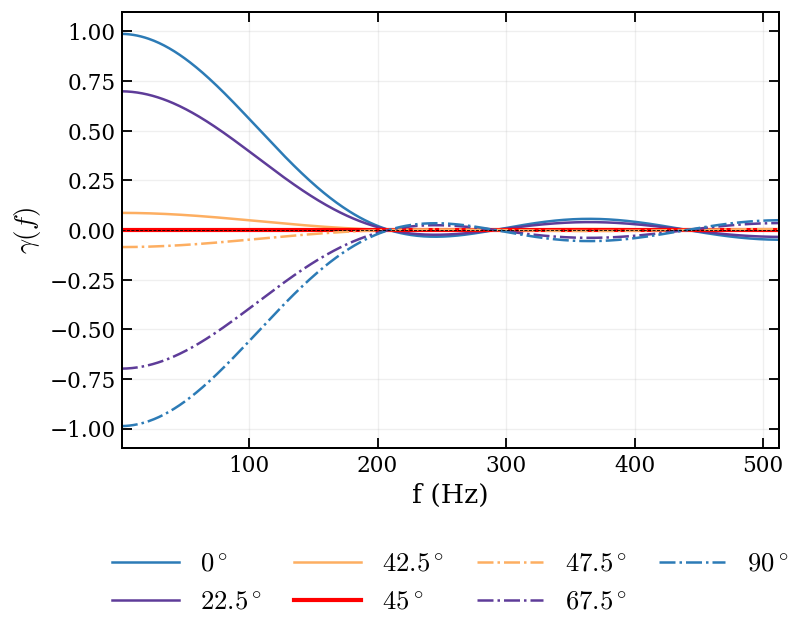

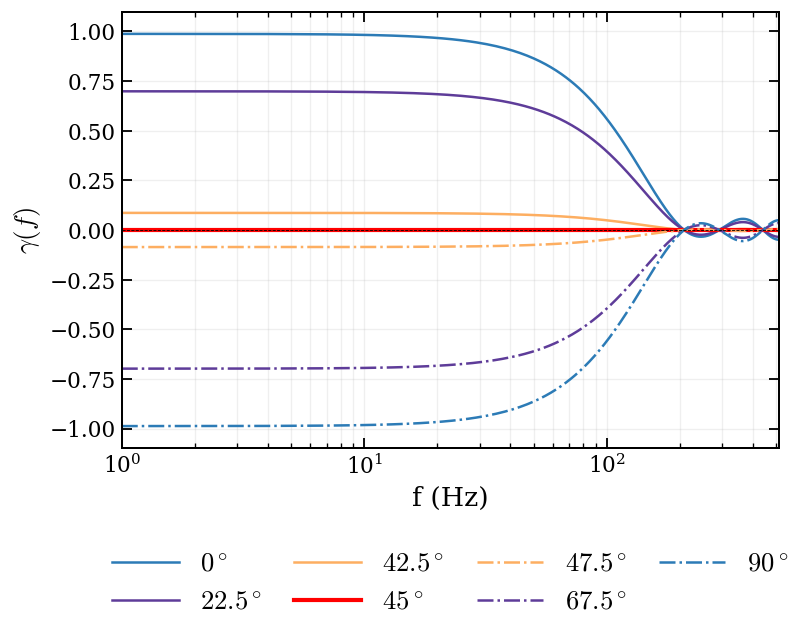

In [8]:
fig, ax = plot_orf(configs, f, scale='linear')
#plt.savefig('ORF_linear.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

fig, ax = plot_orf(configs, f, scale='log')
#plt.savefig('ORF_log.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

## 4. Normalized SNR — Isotropic Background

Starting from
$$\rho^2 = 2T\int_{f_{\rm low}}^{f_{\rm high}} df\,\frac{|\gamma(f,\phi_{\rm rot})|^2\,S_h^2(f)}{P_{n_1}(f)\,P_{n_2}(f)},$$
we set $T=1$, $P_{n_1}=P_{n_2}=1$, $S_h^2\propto f^{-6}$ (i.e. $\Omega_{\rm GW}=\mathrm{const}$), giving

$$\rho(\phi_{\rm rot}) \propto \sqrt{\int_{f_{\rm low}}^{f_{\rm high}} df\;\frac{|\gamma(f,\phi_{\rm rot})|^2}{f^6}}.$$

The normalized SNR $\rho/\rho_{\rm max}$ is shown as a function of $\phi_{\rm rot}$.


In [ ]:
# ── Normalized SNR vs α (1/f^6 weighting) ────────────────────────────────────
from scipy.integrate import trapezoid

f_snr   = np.linspace(10, 100, 200)          # Hz  (f_low=10, f_high=100)
weight  = f_snr**(-6)                         # S_h^2 ∝ f^{-6}, P_n1=P_n2=1

alpha_deg = np.arange(0, 181, 5)             # 0° … 180° in 5° steps
alpha_rad = np.radians(alpha_deg)

snr2 = np.zeros(len(alpha_rad))
print('Computing SNR for each α ...')
for k, a in enumerate(alpha_rad):
    orf_k  = compute_overlap(f_snr, a, method='lw', nside_pix=16)
    snr2[k] = trapezoid(np.abs(orf_k)**2 * weight, f_snr)
    print(f'  α={alpha_deg[k]:5.1f}°  ρ²={snr2[k]:.4e}', flush=True)

snr_norm = np.sqrt(snr2) / np.sqrt(snr2.max())

# ── figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(figsize=(7, 5),
)

ax = axes
ax.plot(alpha_deg, snr_norm, 'o-', ms=4, lw=1.6, color='steelblue')
ax.set_xlabel(r'$\phi_{\rm{rot}}$')
ax.set_ylabel(r'Normalized SNR')
ax.set_xlim(0, 180)
ax.set_ylim(-0.09, 1.05)
ax.grid(True, alpha=0.35)


plt.tight_layout()
#fig.savefig('NormalizedSNR_vs_alpha.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved NormalizedSNR_vs_alpha.pdf')


Computing SNR for each α ...
  α=  0.0°  ρ²=1.9276e-06
  α=  5.0°  ρ²=1.8695e-06
  α= 10.0°  ρ²=1.7021e-06
  α= 15.0°  ρ²=1.4457e-06
  α= 20.0°  ρ²=1.1312e-06
  α= 25.0°  ρ²=7.9645e-07
  α= 30.0°  ρ²=4.8191e-07
  α= 35.0°  ρ²=2.2549e-07
  α= 40.0°  ρ²=5.8125e-08
  α= 45.0°  ρ²=5.0303e-38
  α= 50.0°  ρ²=5.8125e-08
  α= 55.0°  ρ²=2.2549e-07
  α= 60.0°  ρ²=4.8191e-07
  α= 65.0°  ρ²=7.9645e-07


## 5. Beam Matrix with $1/f^6$ Spectral Weighting

The $1/f^6$-weighted beam matrix (instead of writing $\bar{H}(f) \propto f^{-3}$) is

$$B(p,q) = \sum_t \sum_f w_f\,F_{12}(p,t)\,F_{12}(q,t)\,\cos\!\left(\frac{2\pi f\,(\hat{k}_p-\hat{k}_q)\cdot\Delta\mathbf{r}(t)}{c}\right),
\quad w_f \propto f^{-6}$$

where the sum over time $t$ covers one sidereal day (Earth rotation) and $F_{12}(p,t)=F^+_1 F^+_2 + F^\times_1 F^\times_2$ is the combined antenna pattern for sky pixel $p$ at time $t$.

### 5.1 Helper functions


In [ ]:
import os

# ── Earth orbital position ────────────────────────────────────────────────────
def earth_orbit(t):
    """Heliocentric position of Earth at times t [s] → shape (3, N)."""
    wES = 2*np.pi / SIDYR
    x   = AU * np.cos(wES * t)
    y   = AU * np.sin(wES * t)
    rE  = np.zeros((3, t.size))
    rE[0] = x; rE[1] = y*np.cos(OBLIQ); rE[2] = y*np.sin(OBLIQ)
    return rE

# ── Earth spin: z-rotation applied to a 3-vector ─────────────────────────────
def rot_z_vec(vec, cwt, swt):
    """Rotate vec through Earth-spin angles → shape (3, N)."""
    N = len(cwt); out = np.empty((3, N))
    out[0] =  cwt*vec[0] + swt*vec[1]
    out[1] = -swt*vec[0] + cwt*vec[1]
    out[2] =  vec[2]
    return out

# ── Batched rotation R = Ry(θ)·Rz(φ) for all pixels simultaneously ───────────
def rotation_batch(theta_arr, phi_arr):
    P  = len(theta_arr)
    cp = np.cos(phi_arr);  sp = np.sin(phi_arr)
    cx = np.cos(theta_arr); sx = np.abs(np.sin(theta_arr))
    zz = np.zeros(P);  oo = np.ones(P)
    R1 = np.stack([np.stack([ cp, sp, zz], 1),
                   np.stack([-sp, cp, zz], 1),
                   np.stack([ zz, zz, oo], 1)], axis=1)
    R2 = np.stack([np.stack([ cx, zz,-sx], 1),
                   np.stack([ zz, oo, zz], 1),
                   np.stack([ sx, zz, cx], 1)], axis=1)
    return np.einsum('pij,pjk->pik', R2, R1)

# ── Combined antenna pattern F12 and baseline phase k·Δr ─────────────────────
def pattern_kdotr(theta_arr, phi_arr, u1_t, v1_t, u2_t, v2_t, rd):
    """
    Returns
    -------
    F12  : (P, N) — F+1 F+2 + Fx1 Fx2 for each pixel and time
    kdotr: (P, N) — k_hat · Δr(t) [m]
    """
    R   = rotation_batch(theta_arr, phi_arr)
    Ru1 = np.einsum('pij,jn->pin', R, u1_t); Rv1 = np.einsum('pij,jn->pin', R, v1_t)
    Ru2 = np.einsum('pij,jn->pin', R, u2_t); Rv2 = np.einsum('pij,jn->pin', R, v2_t)
    Fp1 = 0.5*((Ru1[:,0,:]**2 - Ru1[:,1,:]**2) - (Rv1[:,0,:]**2 - Rv1[:,1,:]**2))
    Fc1 = 0.5*(2*Ru1[:,0,:]*Ru1[:,1,:] - 2*Rv1[:,0,:]*Rv1[:,1,:])
    Fp2 = 0.5*((Ru2[:,0,:]**2 - Ru2[:,1,:]**2) - (Rv2[:,0,:]**2 - Rv2[:,1,:]**2))
    Fc2 = 0.5*(2*Ru2[:,0,:]*Ru2[:,1,:] - 2*Rv2[:,0,:]*Rv2[:,1,:])
    F12 = 0.5*(Fp1*Fp2 + Fc1*Fc2)
    sx  = np.abs(np.sin(theta_arr)); cp = np.cos(phi_arr); sp = np.sin(phi_arr)
    k   = np.stack([sx*cp, sx*sp, np.cos(theta_arr)], axis=1)
    return F12, np.einsum('pi,in->pn', k, rd)

# ── Dirichlet kernel (equal-weight frequency sum, closed form) ────────────────
def dirichlet_real(D, Nf, fmax):
    """Re Σ_{j=0}^{Nf-1} exp(i 2π j Δf D/c), Δf = fmax/(Nf-1)."""
    if Nf <= 1:
        return np.ones_like(D, dtype=float)
    df    = fmax / (Nf - 1)
    omega = 2*np.pi * df * D / C
    ReS   = np.full_like(D, float(Nf))
    s     = np.abs(omega) > 1e-12
    o     = omega[s]
    ReS[s] = np.sin(Nf*o/2) / np.sin(o/2) * np.cos((Nf-1)*o/2)
    return ReS

# ── 1/f^6 weighted frequency sum ─────────────────────────────────────────────
def weighted_freq_sum(D, f_low=10.0, f_high=100.0, Nf=40):
    """Re Σ_f w_f cos(2π f D/c),  w_f ∝ f^{-6}."""
    freqs  = np.linspace(f_low, f_high, Nf)
    w      = freqs**(-6);  w /= w.sum()
    result = np.zeros_like(D, dtype=float)
    for f, wi in zip(freqs, w):
        result += wi * np.cos(2*np.pi * f * D / C)
    return result

print("Helper functions defined.")


In [ ]:
def compute_beam_matrix_f6(det1, det2, alpha_rad=0.0,
                           N=40, f_low=10.0, f_high=100.0, Nf=40,
                           nside=4, batch_size=32,
                           separation=S_DEFAULT, arm_length=L_DEFAULT):
    """
    Compute the HEALPix beam matrix B(p,q) with 1/f^6 frequency weighting.

    B(p,q) = Σ_t Σ_f  w_f  F12(p,t) F12(q,t) cos(2πf(k_p−k_q)·Δr(t)/c)

    Parameters
    ----------
    det1, det2 : str  — 'A' or 'B'
    alpha_rad  : float — orientation angle φ_rot [rad]
    N          : int  — number of time steps (one sidereal day)
    f_low/high : float — frequency band [Hz]
    Nf         : int  — number of frequency bins
    nside      : int  — HEALPix resolution
    batch_size : int  — pixel batch size for memory efficiency

    Returns
    -------
    B : (npix, npix) ndarray
    """
    npix = hp.nside2npix(nside)
    print(f'  nside={nside} ({npix} px), N={N}, Nf={Nf}, '
          f'f=[{f_low},{f_high}] Hz', flush=True)

    wE  = 2*np.pi / SIDDAY
    t   = np.arange(N) / N * SIDDAY
    cwt = np.cos(-wE*t);  swt = np.sin(-wE*t)

    r1, u1, v1, _ = get_detector(det1, alpha_rad, separation, arm_length)
    r2, u2, v2, _ = get_detector(det2, alpha_rad, separation, arm_length)
    u1_t = rot_z_vec(u1, cwt, swt);  v1_t = rot_z_vec(v1, cwt, swt)
    u2_t = rot_z_vec(u2, cwt, swt);  v2_t = rot_z_vec(v2, cwt, swt)
    rd   = (rot_z_vec(r1, cwt, swt) + earth_orbit(t)
           -rot_z_vec(r2, cwt, swt) - earth_orbit(t))

    tp, pp = hp.pix2ang(nside, np.arange(npix))
    tk = np.pi - tp;  pk = np.pi + pp          # antipodal convention

    F_all  = np.zeros((npix, N))
    kd_all = np.zeros((npix, N))
    nb_    = int(np.ceil(npix / batch_size))
    for b in range(nb_):
        sl = slice(b*batch_size, min((b+1)*batch_size, npix))
        Fp, kd = pattern_kdotr(tk[sl], pk[sl], u1_t, v1_t, u2_t, v2_t, rd)
        F_all[sl] = Fp;  kd_all[sl] = kd

    B = np.zeros((npix, npix))
    for b in range(nb_):
        sl  = slice(b*batch_size, min((b+1)*batch_size, npix))
        Fp  = F_all[sl]
        kdp = kd_all[sl]
        D   = kdp[:, None, :] - kd_all[None, :, :]
        B[sl] = np.einsum('pn,qn,pqn->pq', Fp, F_all,
                          weighted_freq_sum(D, f_low, f_high, Nf))
    return B

print("compute_beam_matrix_f6() ready.")


### 5.2 Beam matrix for selected orientations

In [ ]:
# ── Beam matrix (1/f^6) for α = 0°, 22.5°, 45°, 67.5° ───────────────────────
alphas_bm = [0.0, 22.5, 45.0, 67.5]
Bmats = {}
for adeg in alphas_bm:
    print(f'α={adeg}°...')
    Bmats[adeg] = compute_beam_matrix_f6(
        'A', 'B', alpha_rad=np.radians(adeg),
        N=40, f_low=10.0, f_high=100.0, Nf=40, nside=4
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, adeg in zip(axes.flat, alphas_bm):
    B = Bmats[adeg]
    lim = np.max(np.abs(B))
    im  = ax.imshow(B, cmap='inferno', vmin=0, vmax=lim,
                    aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='B(p,q)')
    ax.set_title(rf'$\alpha={adeg}°$  (1/$f^6$)')
    ax.set_xlabel('Source pixel  q')
    ax.set_ylabel('Response pixel  p')

plt.suptitle('Beam Matrix A–B  with $1/f^6$ weighting  '
             '(nside=4, N=40, f∈[10,100] Hz)', y=1.01)
plt.tight_layout()
#fig.savefig('BeamMatrix_f6.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved BeamMatrix_f6.pdf')


## 6. Normalized SNR — Kinematic Dipole

For the CMB kinematic dipole template $\mathbf{d}$ (Planck 2018), the SNR is

$$\rho(\phi_{\rm rot}) = A\,\sqrt{\mathbf{d}^{\top}B(\phi_{\rm rot})\,\mathbf{d}},
\qquad A = \Omega_{\rm GW}\times\beta,\quad \beta = v/c = 1.23\times10^{-3}.$$

The template is $d_p = \hat{n}_p\cdot\hat{d}$ evaluated at each HEALPix pixel, where $\hat{d}$ points to the dipole apex (RA = 167.94°, Dec = −6.95°).


In [ ]:
# ── CMB kinematic dipole template (Planck 2018) ───────────────────────────
DIPOLE_RA  = 167.94    # deg, ICRS J2000
DIPOLE_DEC = -6.95     # deg
BETA_DIP   = 369.82e3 / C   # v/c = 1.2336e-3

ra_d  = np.radians(DIPOLE_RA)
dec_d = np.radians(DIPOLE_DEC)
d_hat = np.array([np.cos(dec_d)*np.cos(ra_d),
                  np.cos(dec_d)*np.sin(ra_d),
                  np.sin(dec_d)])

def dipole_template(nside, d_hat):
    """d_p = n_hat_p . d_hat for all HEALPix pixels."""
    th, ph = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
    n_vecs = np.column_stack([np.sin(th)*np.cos(ph),
                              np.sin(th)*np.sin(ph),
                              np.cos(th)])
    return n_vecs @ d_hat

NSIDE_DIP  = 4
d_vec = dipole_template(NSIDE_DIP, d_hat)   

print(f'Dipole apex : RA = {DIPOLE_RA} deg,  Dec = {DIPOLE_DEC} deg')
print(f'd_hat (ICRS): {d_hat.round(5)}')
print(f'beta = v/c  : {BETA_DIP:.5e}')
print(f'nside={NSIDE_DIP}  npix={hp.nside2npix(NSIDE_DIP)}')
print(f'd_vec: min={d_vec.min():.3f}  max={d_vec.max():.3f}  '
      f'rms={np.sqrt(np.mean(d_vec**2)):.3f}  (expected 1/sqrt(3)={1/np.sqrt(3):.3f})')


In [ ]:
# ── Beam matrices via compute_beam_matrix_f6 for each alpha ──────────────
import os
ALPHAS_DIP = np.arange(0, 181, 5)   # 0, 5, 10, ..., 90 degrees

CKPT_DIP = '/tmp/dip_bm_f6_ckpts'
os.makedirs(CKPT_DIP, exist_ok=True)

beam_matrices_dip = {}

print(f'Computing {len(ALPHAS_DIP)} beam matrices  '
      f'(nside={NSIDE_DIP}, 1/f^6 weighting, N=40, Nf=30)\n')
for adeg in ALPHAS_DIP:
    path = f'{CKPT_DIP}/B_f6_ns{NSIDE_DIP}_a{int(adeg*10):04d}.npy'
    if os.path.exists(path):
        beam_matrices_dip[adeg] = np.load(path)
        print(f'  [cache] alpha = {adeg:5.1f} deg')
    else:
        print(f'  [calc]  alpha = {adeg:5.1f} deg ...', end='', flush=True)
        B = compute_beam_matrix_f6(
            'A', 'B', alpha_rad=np.radians(adeg),
            N=40, f_low=10.0, f_high=100.0, Nf=30,
            nside=NSIDE_DIP, batch_size=32)
        np.save(path, B)
        beam_matrices_dip[adeg] = B
        print(' done')
print('\nAll beam matrices ready.')


In [ ]:
# ── SNR computation ───────────────────────────────────────────────────────
snr_fac_dip  = np.array([np.sqrt(max(float(d_vec @ B @ d_vec), 0.))
                          for B in beam_matrices_dip.values()])
snr_norm_dip = snr_fac_dip / snr_fac_dip.max()

# Table
print(f'{"alpha":>9}  {"SNR/peak":>10}')
print('-' * 25)
for adeg, sn in zip(ALPHAS_DIP, snr_norm_dip):
    tag = '  <- peak' if sn == snr_norm_dip.max() else (
          '  <- min'  if sn == snr_norm_dip.min() else '')
    print(f'{adeg:>8.1f} d  {sn:>10.4f}{tag}')

pidx = int(np.argmax(snr_norm_dip))

# ── Dipole skymap ─────────────────────────────────────────────────────────
d_display = dipole_template(32, d_hat)   # nside=32 for smooth display

fig_sky = plt.figure(figsize=(7, 5))
hp.mollview(d_display, fig=fig_sky.number,
            title=r'Template for Targeted Search',
            cmap='viridis', cbar=False)
hp.graticule(alpha=0.1)
#plt.savefig('DipoleTemplate_skymap.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved DipoleTemplate_skymap.pdf')

# ── Normalized SNR plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ALPHAS_DIP, snr_norm_dip,
        'o-', ms=4, lw=1.6, color='steelblue')
# ax.axvline(45, color='crimson', ls='--', lw=1.5,
#            label=r'$\alpha=45^\circ$')
# ax.plot(ALPHAS_DIP[pidx], snr_norm_dip[pidx], '*', c='gold', ms=14, zorder=5,
#         label=f'Peak: α = {ALPHAS_DIP[pidx]:.0f}°')
ax.set_xlabel(r'$\phi_{\rm{rot}}$ ')
ax.set_ylabel(r' Normalized SNR')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 180)
ax.set_ylim(-0.09, 1.08)
plt.tight_layout()
#plt.savefig('DipolarSNR_norm_f6.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved DipolarSNR_norm_f6.pdf')


## 7. Point Spread Function & Dirty Maps

The PSF for an injected point source at pixel $p_0$ is the beam-matrix column $B(:,p_0)$, computed here via the Dirichlet-kernel path (equal frequency weights, faster than the explicit $1/f^6$ loop for visualization purposes).

The **dirty map** for an extended signal $s(q)$ is
$$\tilde{s}(p) = \sum_q B(p,q)\,s(q).$$

**HEALPix antipodal convention:** $\theta_k = \pi - \theta_n$, $\phi_k = \pi + \phi_n$.

### 7.1 Core functions


In [ ]:
# ──  PSF function (point source, Dirichlet path) ─────────────────────────
def compute_psf(theta0_deg, phi0_deg, det1, det2, alpha_rad=0.0,
                N=50, Nf=20, fmax=512.0, nside=8, batch_size=512,
                separation=S_DEFAULT, arm_length=L_DEFAULT):
    """
    Point-spread function for a GW radiometer.

    Parameters
    ----------
    theta0_deg, phi0_deg : source colatitude & longitude (degrees)
    det1, det2           : detector names ('H1','L1','A','B',…)
    alpha_rad            : arm rotation angle for det B (radians)
    N                    : time steps over one sidereal day
    Nf                   : frequency bins (Dirichlet kernel)
    fmax                 : max frequency (Hz)
    nside                : HEALPix nside
    """
    wE  = 2*np.pi/SIDDAY
    t   = np.arange(N)/N*SIDDAY
    cwt = np.cos(-wE*t); swt = np.sin(-wE*t)

    r1,u1,v1,_ = get_detector(det1, alpha_rad, separation, arm_length)
    r2,u2,v2,_ = get_detector(det2, alpha_rad, separation, arm_length)
    u1_t = rot_z_vec(u1,cwt,swt); v1_t = rot_z_vec(v1,cwt,swt)
    u2_t = rot_z_vec(u2,cwt,swt); v2_t = rot_z_vec(v2,cwt,swt)
    r1_t = rot_z_vec(r1,cwt,swt) + earth_orbit(t)
    r2_t = rot_z_vec(r2,cwt,swt) + earth_orbit(t)
    rd   = r1_t - r2_t

    npix = hp.nside2npix(nside)
    tp,pp = hp.pix2ang(nside, np.arange(npix))
    # antipodal k-hat
    theta_k = np.pi - tp;  phi_k = np.pi + pp
    theta0_k = np.pi - theta0_deg*np.pi/180
    phi0_k   = np.pi + phi0_deg  *np.pi/180

    F0, kd0 = pattern_kdotr(np.array([theta0_k]), np.array([phi0_k]),
                              u1_t, v1_t, u2_t, v2_t, rd)
    F0 = F0[0]; kd0 = kd0[0]

    psf = np.zeros(npix)
    nb  = int(np.ceil(npix/batch_size))
    for b in range(nb):
        sl = slice(b*batch_size, min((b+1)*batch_size, npix))
        Fp, kdp = pattern_kdotr(theta_k[sl], phi_k[sl], u1_t,v1_t,u2_t,v2_t, rd)
        D   = kd0[None,:] - kdp
        ReS = dirichlet_real(D, Nf, fmax)
        psf[sl] = np.einsum('pn,n,pn->p', Fp, F0, ReS)
    return psf

print("compute_psf() defined.")


In [ ]:
# ── Dirty map functions ───────────────────────────────────────────────────────
def _build_time_series(det1, det2, alpha_rad, N, separation, arm_length):
    wE  = 2*np.pi/SIDDAY; t = np.arange(N)/N*SIDDAY
    cwt = np.cos(-wE*t); swt = np.sin(-wE*t)
    r1,u1,v1,_ = get_detector(det1,alpha_rad,separation,arm_length)
    r2,u2,v2,_ = get_detector(det2,alpha_rad,separation,arm_length)
    u1_t = rot_z_vec(u1,cwt,swt); v1_t = rot_z_vec(v1,cwt,swt)
    u2_t = rot_z_vec(u2,cwt,swt); v2_t = rot_z_vec(v2,cwt,swt)
    r1_t = rot_z_vec(r1,cwt,swt) + earth_orbit(t)
    r2_t = rot_z_vec(r2,cwt,swt) + earth_orbit(t)
    return u1_t, v1_t, u2_t, v2_t, r1_t-r2_t

def compute_dirty_map(signal_map, f_arr,
                      u1_t, v1_t, u2_t, v2_t, rd,
                      theta_khat, phi_khat, batch_size=512):
    """
    D(f,t) = Σ_q s(q)·F12(q,t)·exp(-i2πf k_q·Δr/c)
    dirty(p) = Re Σ_{f,t} F12(p,t)·exp(+i2πf k_p·Δr/c)·D(f,t)
    """
    npix = len(signal_map); N = u1_t.shape[1]; Nf = len(f_arr)
    D    = np.zeros((Nf, N), dtype=complex)
    nb   = int(np.ceil(npix/batch_size))
    # forward pass: accumulate D(f,t)
    for b in range(nb):
        sl  = slice(b*batch_size, min((b+1)*batch_size, npix))
        Fp, kdq = pattern_kdotr(theta_khat[sl], phi_khat[sl],
                                 u1_t,v1_t,u2_t,v2_t, rd)     # (P,N)
        phase = np.exp(-1j*2*np.pi * f_arr[None,:,None] * kdq[:,None,:] / C)
        w     = signal_map[sl,None] * Fp                        # (P,N) → broadcast
        D    += np.einsum('pn,pfn->fn', w, phase)
    # back-projection
    dirty = np.zeros(npix)
    for b in range(nb):
        sl = slice(b*batch_size, min((b+1)*batch_size, npix))
        Fp, kdp = pattern_kdotr(theta_khat[sl], phi_khat[sl],
                                 u1_t,v1_t,u2_t,v2_t, rd)
        cp    = np.exp(+1j*2*np.pi * f_arr[None,:,None] * kdp[:,None,:] / C)
        dirty[sl] = np.real(np.einsum('pfn->p',
                                Fp[:,None,:] * cp * D[None,:,:]))
    return dirty

print("Dirty-map functions defined.")


### 7.2 Visualization helpers

In [ ]:
import io
from PIL import Image

def mollview_to_img(m, title, vmin, vmax, cmap='RdBu_r', figsize=(9,5)):
    """Render a HEALPix map to a PIL image (no individual colorbar)."""
    fig = plt.figure(figsize=figsize)
    hp.mollview(m, fig=fig.number, title=title, cmap=cmap,
                min=vmin, max=vmax, unit='', hold=True, cbar=False)
    hp.graticule(dpar=30, dmer=60, alpha=0.4)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig); buf.seek(0)
    return Image.open(buf).copy()


def row_plot(imgs, out_path, suptitle='',
             cmap='RdBu_r', vmin=0, vmax=1, cbar_label=''):
    """Stitch PIL images horizontally + single horizontal colorbar."""
    total_w = sum(im.width for im in imgs)
    h       = max(im.height for im in imgs)
    canvas  = Image.new('RGB', (total_w, h), (255,255,255))
    x = 0
    for im in imgs:
        canvas.paste(im, (x, 0)); x += im.width
    arr = np.array(canvas)
    fw = total_w / 150; fh = h / 150
    fig = plt.figure(figsize=(fw, fh + 0.6))
    ax      = fig.add_axes([0.0,  0.10, 1.0, 0.90])
    cbar_ax = fig.add_axes([0.10, 0.03, 0.80, 0.04])
    ax.imshow(arr); ax.axis('off')
    if suptitle:
        ax.set_title(suptitle, fontsize=11, pad=4)
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label=cbar_label)
    #fig.savefig(out_path, dpi=150, bbox_inches='tight', pad_inches=0.02)
    plt.show()
    print(f'Saved {out_path}')

print('Visualization helpers defined.')


### 7.3 Point source PSF — α = 0°, 22.5°, 45°

In [ ]:
# ── PSF: point source injection ─────────────────────────────────────────────
nside_psf = 16;  N_psf = 50;  Nf_psf = 20;  fmax_psf = 512.0
theta0_deg = 90.;  phi0_deg = 100.
alphas_psf = [0.0, 22.5, 45.0]

print('Computing PSF (point source)...')
psf_maps = []
for adeg in alphas_psf:
    print(f'  α={adeg}°', flush=True)
    m = compute_psf(theta0_deg, phi0_deg, 'A', 'B',
                    alpha_rad=np.radians(adeg),
                    N=N_psf, Nf=Nf_psf, fmax=fmax_psf, nside=nside_psf)
    psf_maps.append(m)

psf_vmax = max(np.abs(m).max() for m in psf_maps)

# injection map
npix_psf = hp.nside2npix(nside_psf)
inj_map  = np.zeros(npix_psf)
inj_map[hp.ang2pix(nside_psf, np.radians(theta0_deg), np.radians(phi0_deg))] = psf_vmax

imgs = [mollview_to_img(inj_map,
                        f'Injected Point Source',
                        0, psf_vmax, cmap='viridis')]
for adeg, psf in zip(alphas_psf, psf_maps):
    imgs.append(mollview_to_img(psf, rf'Point Spread Function  $\phi_{{\rm rot}}={adeg}^\circ$',
                                0, psf_vmax, cmap='viridis'))

row_plot(imgs, 'PSF_pointsource_row.pdf',
         cmap='viridis', vmin=0, vmax=psf_vmax, cbar_label='PSF')


### 7.4 Extended source — galactic plane dirty map

In [ ]:
# ── Dirty map: galactic-plane injection ──────────────────────────────────────
# build galaxy map in equatorial HEALPix
tp_eq, pp_eq = hp.pix2ang(nside_psf, np.arange(hp.nside2npix(nside_psf)))
b_deg = 90. - np.degrees(hp.Rotator(coord=['C','G'])(tp_eq, pp_eq)[0])
gal_map = np.exp(-0.5*(b_deg/10.)**2)

f_arr_psf = np.linspace(0, fmax_psf, Nf_psf)

print('Computing dirty maps (galaxy)...')
dirty_maps = []
for adeg in alphas_psf:
    print(f'  α={adeg}°', flush=True)
    u1_t,v1_t,u2_t,v2_t,rd = _build_time_series(
        'A','B', np.radians(adeg), N_psf, S_DEFAULT, L_DEFAULT)
    tp,pp = hp.pix2ang(nside_psf, np.arange(hp.nside2npix(nside_psf)))
    tk = np.pi-tp; pk = np.pi+pp
    dirty = compute_dirty_map(gal_map, f_arr_psf,
                               u1_t,v1_t,u2_t,v2_t,rd, tk,pk)
    dirty_maps.append(dirty)

dirty_vmax = max(np.abs(d).max() for d in dirty_maps)
gal_display = gal_map / gal_map.max() * dirty_vmax

imgs_gal = [mollview_to_img(gal_display,
                            'Injected Extended Source',
                            0, dirty_vmax, cmap='viridis')]
for adeg, dm in zip(alphas_psf, dirty_maps):
    imgs_gal.append(mollview_to_img(dm, rf'Point Spread Function  $\phi_{{\rm rot}}={adeg}^\circ$',
                                    0, dirty_vmax, cmap='viridis'))

row_plot(imgs_gal, 'PSF_galaxymap_row.pdf',
         cmap='viridis', vmin=0, vmax=dirty_vmax, cbar_label='Dirty map')
